## 写在前面：

### 本深度卷积对抗生成神经网络极大程度上基于：

- Radford et al. (2016). "Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks"
  - Link: https://arxiv.org/abs/1511.06434

其中大部分参数设置从文章的第四部分：

        4.DETAILS OF ADVERSARIAL TRAINING

中直接引用。包括但不限于：

        生成器和判别器的学习率

        Adam优化器的一阶，二阶衰减率

        源数据（手写数字）（见原论文最后第八部分）

### 关于与其他机器学习方法，如普通的对抗式生成神经网络的对比，则由于时间和精力的原因尚未进行。

在此，我简单粗暴地相信原始论文中给出的结果：DCGAN效果比单纯的GAN好（见原始论文第6部分表格，第8部分表格）

### 关于其他参数的设置

大部分会在代码中给出意义和理由，大部分直接来源于原始论文的建议。

少部分未加标识的，则可能是我忘了，也可能可以随意更改，比如epoch。

### 关于训练结果

受限于时间和设备，使用简单的30epoch进行训练。得到的结果存储在Run/文件夹中。

Using GPU For Training.(Computer Broken Can't Type CHINESE Suddenly)

IF USE CPU, might take extremly long time. Might just jump to the end use the TRAINED MODEL in /Run folder.

### 关于卷积的处理

本身只是把卷积后的数据喂到GAN中，卷积中使用的torch包特殊函数，如 LeakyReLU 等的数据结构由AI读取后生成在Relinear.ipynb中，用于参考和理解。

至于用到的特殊函数，大部分会在本NoteBook中代码的对应部分给出注释，有时与参数的设置理由一并给出。






In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. 配置

## 原始DCGAN论文第四部分记录相关参数设置：
### 4.DETAILS OF ADVERSARIAL TRAINING

No pre-processing was applied to training images besides scaling to the range of the tanh activation
function [-1, 1]. All models were trained with mini-batch stochastic gradient descent (SGD) with
a mini-batch size of 128. All weights were initialized from a zero-centered Normal distribution
with standard deviation 0.02. In the LeakyReLU, the slope of the leak was set to 0.2 in all models.
While previous GAN work has used momentum to accelerate training, we used the Adam optimizer
(Kingma & Ba, 2014) with tuned hyperparameters. We found the suggested learning rate of 0.001,
to be too high, using 0.0002 instead. Additionally, we found leaving the momentum term β1 at the suggested value of 0.9 resulted in training oscillation and instability while reducing it to 0.5 helped
stabilize training.

In [ ]:
class Config:
    # 数据
    batch_size = 64 # 批次大小
    img_size = 28 # 图像尺寸
    channels = 1
    
    # 模型
    latent_dim = 100 # 隐空间维度

    '''
    AI 生成的 隐空间维度解释：

    真实数据分布 P_data(x) 存在于高维空间（如28×28=784维）

    隐空间假设：数据实际分布在一个低维流形上
    latent_dim就是这个低维流形的“内在维度”

    例如MNIST：
    - 像素空间：784维
    - 内在维度：约10-100维（只需要这些维度就能描述所有数字变化）

    '''

    '''
    我的理解：
    设置低维空间latent dim（LD），用GAN寻找LD到真实空间的映射，本质上是一个降维+生成过程。

    使用低维空间可以可以简化各数据关联，我说平面化扁平化脸谱化是对的（


    虽然但是，似乎扁平化的信息之间的关联会随着维度的降低，两个数据点距离之间的增加而更难找到
    盲猜一个分散焦点图像不适合卷积
    '''
    g_features = 128 #卷积层输出通道数（G）
    d_features = 64 #卷积层输出通道数（D）、
    dropout = 0.3
    
    # 训练
    epochs = 30
    g_lr = 0.0009 # 学习率 -- 0.0002为DCGAN论文推荐值
    d_lr = 0.0002
    # --摘录如下：
    #We found the suggested learning rate of 0.001,
    #to be too high, using 0.0002 instead.

    beta1 = 0.5 # Adam优化器一阶矩估计的衰减率，见4.训练函数 For Details, if = 0.9, Unstable(According to DCGAN Paper)
    
    # 标签平滑
    # 标签的作用是让交叉商变为平滑过度，避免训练爆炸
    real_label = 0.9
    fake_label = 0.1
    
    # Save Interval
    save_interval = 500
    save_model_interval = 10

cfg = Config()
print(f'Config: batch={cfg.batch_size}, epochs={cfg.epochs}, latent={cfg.latent_dim}')

Config: batch=64, epochs=30, latent=100


## 2. 架构定义

In [39]:
class Generator(nn.Module):
    """从隐向量生成图像"""
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(cfg.latent_dim, cfg.g_features * 7 * 7)
        
        self.main = nn.Sequential(
            # (B, 128, 7, 7)
            nn.BatchNorm2d(cfg.g_features), 
            # BatchNorm2d用于维度维持为G输出层维度‘cfg.g_features’，未正式开始卷积
            nn.ReLU(True), # 激活函数
            nn.Upsample(scale_factor=2),
            nn.Conv2d(cfg.g_features, cfg.g_features, 3, padding=1),
            # 3 为卷积核大小，可以随便改，别是1就行
            # 选取 3 是为了训练快点
            
            # (B, 128, 14, 14)
            nn.BatchNorm2d(cfg.g_features),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(cfg.g_features, cfg.g_features // 2, 3, padding=1),
            
            # (B, 64, 28, 28)
            nn.BatchNorm2d(cfg.g_features // 2),
            nn.ReLU(True),
            nn.Conv2d(cfg.g_features // 2, cfg.channels, 3, padding=1),
            nn.Tanh()
            # tanh 作为激活函数，选择的原因很大程度上在输出(-1,1)，且对称，适合图像生成
        )
    

        '''
            关于初始化函数：

            Conv2d, BatchNorm2d: 卷积采样，获取数据.在不同分辨率上学习数字的特征

            tanh: 规范输出到-1,1，便于输出图像
        '''


    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), cfg.g_features, 7, 7)
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # (B, 1, 28, 28) → (B, 64, 14, 14)
            nn.Conv2d(cfg.channels, cfg.d_features, 4, 2, 1),  #开始卷积
            nn.LeakyReLU(0.2),  # 非线性激活，允许小的负值梯度
            # 负斜率=0.2	防止神经元死亡 
            # 参数来源仍然为DCGAN原始u论文
            nn.Dropout2d(cfg.dropout),  # 添加dropout防止过拟合
            
            # → (B, 128, 7, 7)
            nn.Conv2d(cfg.d_features, cfg.d_features * 2, 4, 2, 1),
            nn.BatchNorm2d(cfg.d_features * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(cfg.dropout),
            
            # → (B, 256, 3, 3)
            nn.Conv2d(cfg.d_features * 2, cfg.d_features * 4, 4, 2, 1),
            nn.BatchNorm2d(cfg.d_features * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(cfg.dropout),
            
            # → (B, 512, 1, 1)  # 3-4+2=1, /2=0.5, floor=0, +1=1
            nn.Conv2d(cfg.d_features * 4, cfg.d_features * 8, 4, 2, 1),
            nn.BatchNorm2d(cfg.d_features * 8),
            nn.LeakyReLU(0.2),
        )
        self.fc = nn.Linear(cfg.d_features * 8 * 1 * 1, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.main(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return self.sigmoid(x)
    
G = Generator().to(device)
D = Discriminator().to(device)

print(f'Generator params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator params: 856,065
Discriminator params: 2,756,801


## 3. 数据加载

Data: 60000 samples, 938 batches


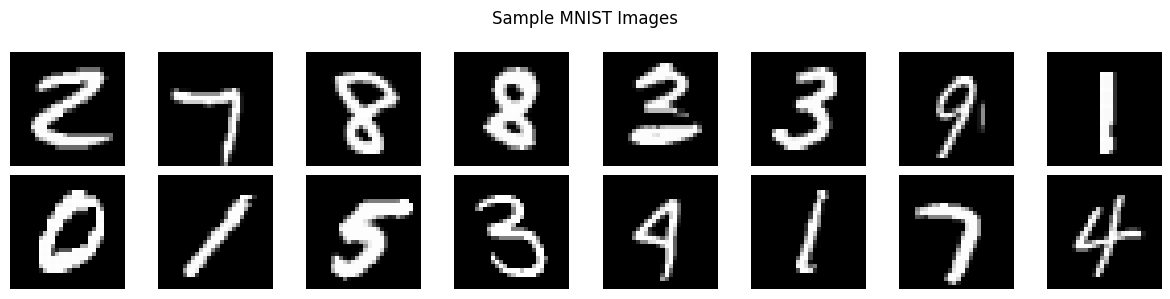

In [40]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True, num_workers=2)

print(f'Data: {len(train_data)} samples, {len(train_loader)} batches')

# 可视化样本
sample_batch, _ = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

## 4. 训练函数

In [41]:
criterion = nn.BCELoss() #交叉熵损失函数

# 自适应矩估计优化器Adam
opt_g = optim.Adam(G.parameters(), lr=cfg.g_lr, betas=(cfg.beta1, 0.999))
opt_d = optim.Adam(D.parameters(), lr=cfg.d_lr, betas=(cfg.beta1, 0.999))
# betas = (0.5, 0.999) 是Adam优化器中一阶和二阶矩估计的衰减率参数设置，常用于GAN训练以提高稳定性。
# beta1 = 0.9 为DCGAN论文原始值，推荐0.5为了稳定性。
# beta2 = 0.999 为Adam优化器默认值，写出来单纯为了占位，未进行更改实验
# ---------------原文摘录如下------------------
# Additionally, we found leaving the momentum term β1 at the suggested value of 0.9 resulted in training oscillation and instability while reducing it to 0.5 helped
# stabilize training.

# 固定噪声：用于生成固定序列，观察训练过程中模型的进度
fixed_noise = torch.randn(64, cfg.latent_dim, device=device)

# 记录指标
metrics = defaultdict(list)


def train_epoch(epoch):
    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        real_labels = torch.full((batch_size, 1), 0.9, device=device) # 生成 batch_size * 1，用0.9填充，标记为真
        fake_labels = torch.full((batch_size, 1), 0.1, device=device)
        
        # ---------------------以下为判别器------------- -----
        opt_d.zero_grad()
        
        # 真实图片
        real_pred = D(real_imgs)
        loss_d_real = criterion(real_pred, real_labels) # 真实图片，标签为真 == 0.9
        
        # 生成图片（用于判别器训练）
        z = torch.randn(batch_size, cfg.latent_dim, device=device)
        with torch.no_grad():  # 不计算生成器梯度，防止生成器在未完成本次迭代前被更新
            fake_imgs = G(z)

        
        fake_pred = D(fake_imgs)
        loss_d_fake = criterion(fake_pred, fake_labels)
        
        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)  # 梯度裁剪
        opt_d.step()
        # ---------------------以上为判别器------------- -----
        
        
        
        # ------------------------------ 以下为生成器 ----------------------
        opt_g.zero_grad()
        
        # 重新生成图片（用于生成器训练）
        z_new = torch.randn(batch_size, cfg.latent_dim, device=device)
        fake_imgs_new = G(z_new)
        fake_pred_new = D(fake_imgs_new)
        loss_g = criterion(fake_pred_new, real_labels)  # 希望判别器认为是真的
        # ------------------------------ 以上为生成器 ----------------------

        # ----------------------------- 反向传播与优化 ----------------------
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)  # 梯度裁剪
        # 防止梯度爆炸，将梯度范数限制在1.0以内
        # 1.0为常用限制，可随情况调整

        opt_g.step()
        metrics['d_loss'].append(loss_d.item())
        metrics['g_loss'].append(loss_g.item())
        metrics['real_acc'].append((real_pred > 0.5).float().mean().item())
        metrics['fake_acc'].append((fake_pred < 0.5).float().mean().item())
        
        # 输出
        if batch_idx % cfg.save_interval == 0:
            avg_d = np.mean(metrics['d_loss'][-100:])
            avg_g = np.mean(metrics['g_loss'][-100:])
            print(f'[{epoch:2d}] Batch {batch_idx:3d}: D={avg_d:.4f}, G={avg_g:.4f}')


def generate_samples(n=64, use_fixed=False):
    """生成样本
        n: 样本数量，完全平方数比较好
        use_fixed: 是否使用固定噪声（用于观察训练进度）
    """
    G.eval()
    with torch.no_grad():
        if use_fixed:
            z = fixed_noise[:n]  # 使用固定噪声
        else:
            z = torch.randn(n, cfg.latent_dim, device=device) # 使用随机噪声，每次训练生成不一样
        samples = G(z).cpu()
    return samples

def plot_samples(use_fixed=True):
    """可视化生成的样本
    Args:
        use_fixed: 是否使用固定噪声（默认使用，便于对比训练过程）
    """
    samples = generate_samples(64, use_fixed=use_fixed)
    samples = (samples + 1) / 2  # [-1, 1] -> [0, 1]
    
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    return fig

print('Training functions ready')

Training functions ready


## 5. 开始训练

In [42]:
folder = 'Run'
print(cfg.dropout)
print(cfg.d_lr)
print(cfg.g_lr)

0.3
0.0002
0.0009


In [43]:

for epoch in range(cfg.epochs):
    train_epoch(epoch)
    
    if (epoch + 1) % cfg.save_model_interval == 0:
        fig = plot_samples()
        plt.savefig(f'dcgan_epoch_{epoch}.png')
        plt.close()
        
        torch.save(G.state_dict(), f'{folder}/G_epoch_{epoch}.pth')
        torch.save(D.state_dict(), f'{folder}/D_epoch_{epoch}.pth')
        print(f'✓ Epoch {epoch} saved')

print('\n✓ Training completed')

# 运行输出意义：D：判别器损失函数，G：生成器损失函数。
# 理想情况下的D：- 理想：0.3~0.8（不断波动）
#              - 异常：接近0（判别器太强）或 >2.0（判别器太弱）--- 更改drop，判别器学习率d_lr
#           G：- 理想：0.3~0.8（与D_loss竞争）
#             - 异常：持续上升（生成器无法学习）
#             - 异常：接近0（可能模式坍缩）

[ 0] Batch   0: D=0.7449, G=0.9499
[ 0] Batch 500: D=0.6860, G=0.7101
[ 0] Batch 500: D=0.6860, G=0.7101
[ 1] Batch   0: D=0.6761, G=0.7247
[ 1] Batch   0: D=0.6761, G=0.7247
[ 1] Batch 500: D=0.6689, G=0.7339
[ 1] Batch 500: D=0.6689, G=0.7339
[ 2] Batch   0: D=0.6632, G=0.7518
[ 2] Batch   0: D=0.6632, G=0.7518
[ 2] Batch 500: D=0.6598, G=0.7650
[ 2] Batch 500: D=0.6598, G=0.7650
[ 3] Batch   0: D=0.6599, G=0.7673
[ 3] Batch   0: D=0.6599, G=0.7673
[ 3] Batch 500: D=0.6591, G=0.7706
[ 3] Batch 500: D=0.6591, G=0.7706
[ 4] Batch   0: D=0.6581, G=0.7687
[ 4] Batch   0: D=0.6581, G=0.7687
[ 4] Batch 500: D=0.6577, G=0.7765
[ 4] Batch 500: D=0.6577, G=0.7765
[ 5] Batch   0: D=0.6597, G=0.7786
[ 5] Batch   0: D=0.6597, G=0.7786
[ 5] Batch 500: D=0.6601, G=0.7844
[ 5] Batch 500: D=0.6601, G=0.7844
[ 6] Batch   0: D=0.6594, G=0.7784
[ 6] Batch   0: D=0.6594, G=0.7784
[ 6] Batch 500: D=0.6545, G=0.7825
[ 6] Batch 500: D=0.6545, G=0.7825
[ 7] Batch   0: D=0.6538, G=0.7852
[ 7] Batch   0: D=0.

## 如果判别器，生成器的损失函数出现异常：



D～0：判别器过强。需要：

        Dropout +

        d_lr -

D>2：判别器过弱。需要：

        相反



G快速<0.2，且D也较小（模式坍塌（Mode Collapse））：
        
''''''

AI告诉我：

症状：G损失快速降至很低（如<0.2）且稳定，D损失也处于低位；生成图像多样性差，大量重复。

根本原因：生成器找到判别器的某个“漏洞”，仅反复生成能骗过判别器的少数样本，放弃了多样性。
调整策略：

增加隐空间维度：提供更丰富的随机种子，鼓励生成器探索更多模式。

添加多样性正则化：引入小批量判别（Minibatch Discrimination）或特征匹配（Feature Matching）损失。

加入历史信息：在判别器中存储并比较历史生成样本，防止生成器重复“旧招”。

调整噪声采样：对隐变量z施加微小扰动或使用截断技巧，避免生成器固守局部最优。

平衡判别器更新：适当降低判别器的学习率，使其更新更平稳，不给生成器留出固定“捷径”。

''''''


D，G均不下降：

''''''

AI告诉我：

症状：D损失和G损失均无下降趋势，在大范围内周期性剧烈波动（如0.3 ↔ 2.0）。
根本原因：优化过程不稳定，两个网络的学习动态互相干扰、互相放大。
调整策略：

大幅降低学习率：同时降低D和G的学习率（如降至1e-4或更低），这是最直接有效的方法。

使用更强的梯度约束：对判别器施加梯度惩罚（Gradient Penalty），或使用谱归一化（Spectral Normalization）稳定其学习。

调整优化器动量：将Adam的beta1参数进一步降低（如从0.5降至0.0），减少动量带来的振荡惯性。

增大批次大小：批次越大，梯度估计越平稳，有助于稳定训练。

检查数据预处理：确保输入数据归一化范围（如[-1,1]）与生成器输出激活函数（如Tanh）完全匹配。

''''''

### 实际运行中：

初次训练遇到问题

    D～0.5,正常。

    但G～1.2且缓慢上升。

解决方法：

    保持dropout(0.3)不变（因为发现增大到0.4的话会导致D大幅上升。

    增加g_lr到0.009.

    结果：
        D～0.7

        G～0.8且缓慢上升

仍有继续优化空间

AI提供了另一个解决方法：

    可以每次训练让生成器训练两次，判别器训练一次，

但更改训练函数较为麻烦，暂时不管

## 6. 结果分析（绘图函数由AI生成）

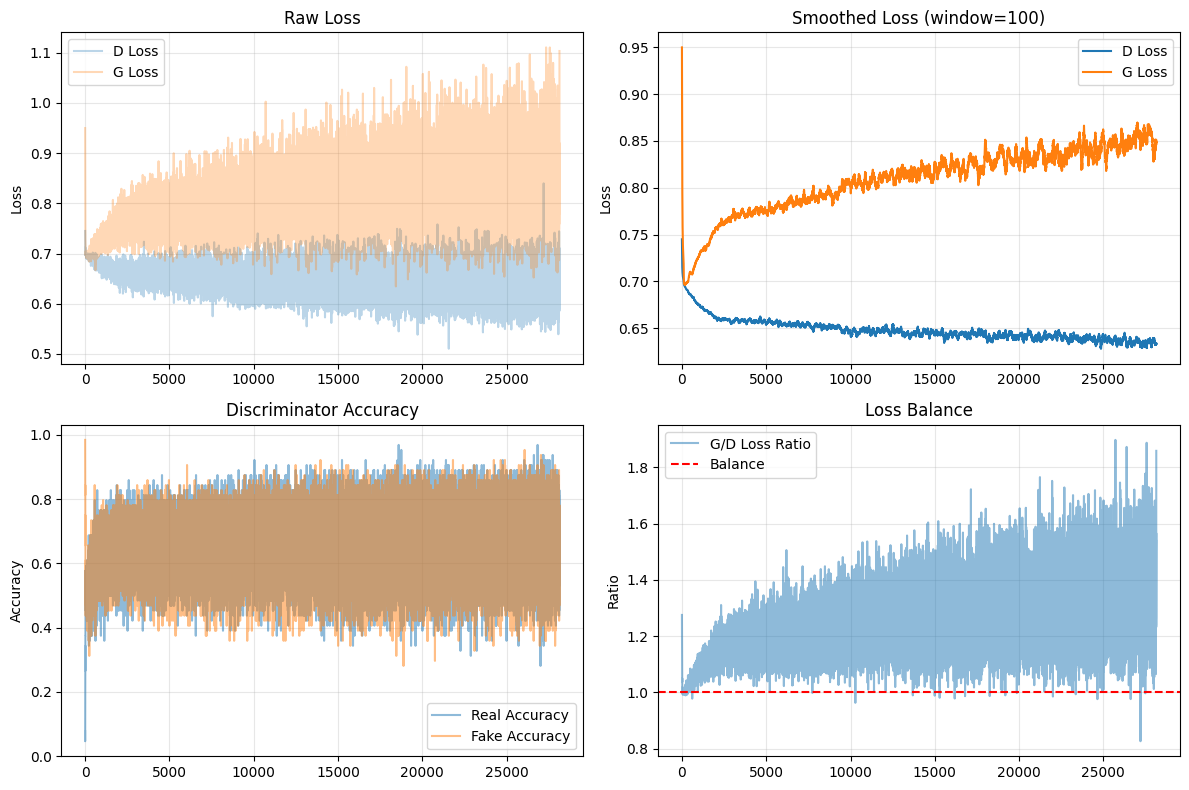


Training Statistics:
  Final D Loss: 0.5935
  Final G Loss: 1.1033
  Avg Real Accuracy: 66.51%
  Avg Fake Accuracy: 64.99%


In [45]:
# 绘图函数由AI生成

# 绘制损失曲线
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 原始损失
ax = axes[0, 0]
ax.plot(metrics['d_loss'], alpha=0.3, label='D Loss')
ax.plot(metrics['g_loss'], alpha=0.3, label='G Loss')
ax.set_ylabel('Loss')
ax.set_title('Raw Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 平滑损失
ax = axes[0, 1]
window = 100
smooth_d = [np.mean(metrics['d_loss'][max(0, i-window):i+1]) for i in range(len(metrics['d_loss']))]
smooth_g = [np.mean(metrics['g_loss'][max(0, i-window):i+1]) for i in range(len(metrics['g_loss']))]
ax.plot(smooth_d, label='D Loss')
ax.plot(smooth_g, label='G Loss')
ax.set_ylabel('Loss')
ax.set_title(f'Smoothed Loss (window={window})')
ax.legend()
ax.grid(True, alpha=0.3)

# 准确率
ax = axes[1, 0]
ax.plot(metrics['real_acc'], alpha=0.5, label='Real Accuracy')
ax.plot(metrics['fake_acc'], alpha=0.5, label='Fake Accuracy')
ax.set_ylabel('Accuracy')
ax.set_title('Discriminator Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# 损失比率
ax = axes[1, 1]
ratio = [g / (d + 1e-8) for g, d in zip(metrics['g_loss'], metrics['d_loss'])]
ax.plot(ratio, alpha=0.5, label='G/D Loss Ratio')
ax.axhline(y=1.0, color='r', linestyle='--', label='Balance')
ax.set_ylabel('Ratio')
ax.set_title('Loss Balance')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{folder}/training_analysis.png', dpi=100)
plt.show()

print('\nTraining Statistics:')
print(f'  Final D Loss: {metrics["d_loss"][-1]:.4f}')
print(f'  Final G Loss: {metrics["g_loss"][-1]:.4f}')
print(f'  Avg Real Accuracy: {np.mean(metrics["real_acc"]):.2%}')
print(f'  Avg Fake Accuracy: {np.mean(metrics["fake_acc"]):.2%}')

## 7. 推理

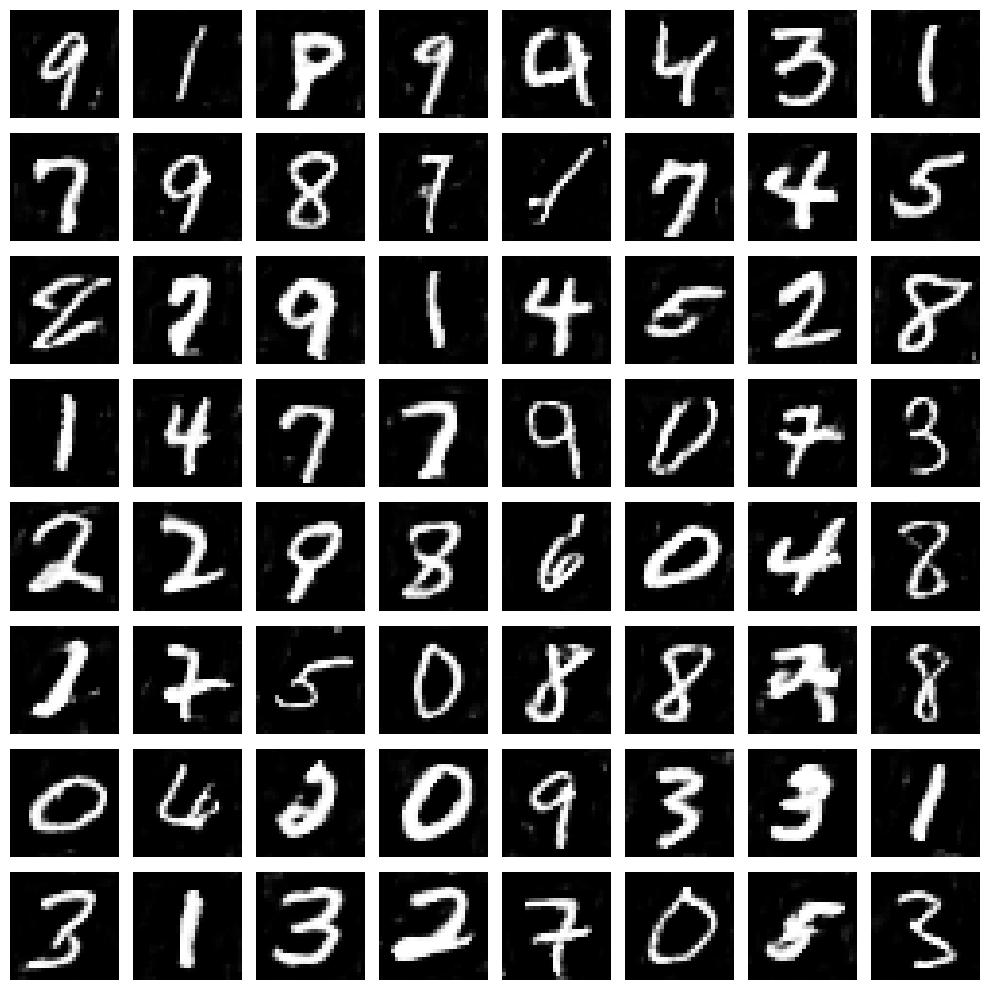

✓ Models saved


In [46]:
# 生成最终样本
fig = plot_samples()
plt.savefig(f'{folder}/final_samples.png', dpi=120)
plt.show()

# 保存模型
torch.save(G.state_dict(), f'{folder}/G_final.pth')
torch.save(D.state_dict(), f'{folder}/D_final.pth')
print('✓ Models saved')

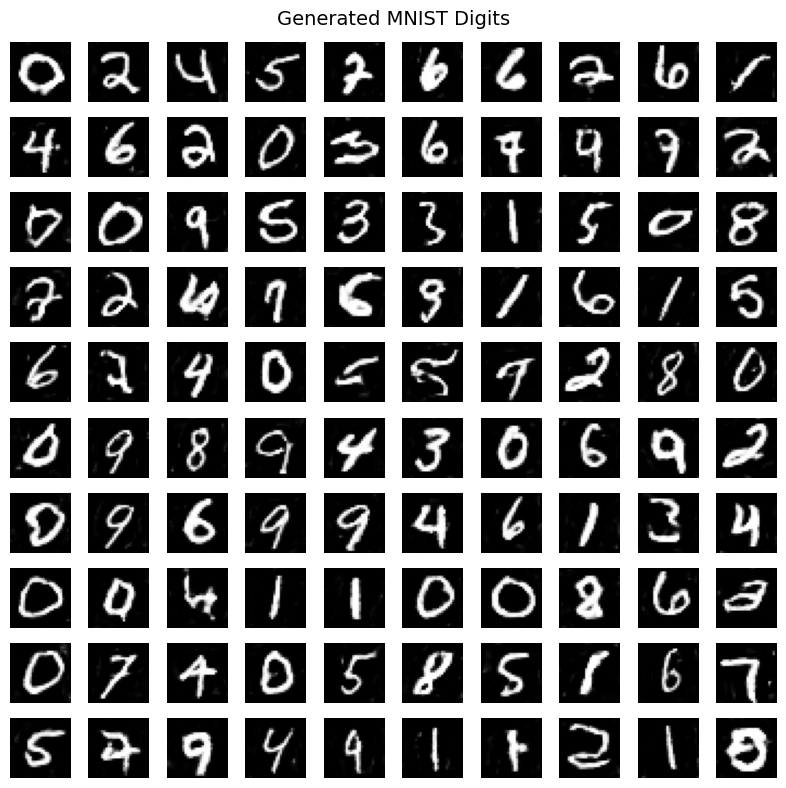

In [ ]:
# 从保存的模型加载和生成（AI写的函数，自己有更改定制）
def load_and_generate(model_path, n_samples=16):
    """加载模型并生成样本"""
    G_loaded = Generator().to(device)
    G_loaded.load_state_dict(torch.load(model_path, map_location=device))
    G_loaded.eval()
    
    with torch.no_grad():
        z = torch.randn(n_samples, cfg.latent_dim, device=device)
        samples = G_loaded(z).cpu()
    
    samples = (samples + 1) / 2
    
    grid_size = int(np.sqrt(n_samples))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].squeeze(), cmap='gray')
        ax.axis('off')
    fig.suptitle('Generated MNIST Digits', fontsize=14, y=0.98)
    plt.tight_layout()
    return fig, samples

# 使用示例
fig, samples = load_and_generate(f'{folder}/G_final.pth', 100)
plt.show()